In [1]:
import pandas as pd 
new20groups = pd.read_csv("./data/20newsgroups.csv")
stop_words_df = pd.read_csv("./data/stopwords.csv")

In [2]:
import fonction_pretraitement as pretraitement
groupes_filtre = pretraitement.filtre(new20groups, stop_words_df)
groupes20 = pretraitement.organiser(groupes_filtre)

In [3]:
groupes20.keys()
# structure : dict * dict * mot 
# dictionnaire dont clé = groupe et valeur : dict de liste de mots

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])

In [4]:
# Classement des mots les plus utilisés dans chaque groupe 
## binaire, comptage, tf-idf ? 
#L’objectif de cette étape est d’identifier, pour chaque groupe de documents, 
#les mots les plus représentatifs de son contenu. #Trois approches principales ont été 
#envisagées pour effectuer ce classement :

In [5]:
"""
Binaire : 
Avantage : simple et rapide 
Limite : ignore la fréquence réelle d'un mot dans un meme document 

Comptage: 
Avantage : reflète les mots les plus souvent utilisés 
Limite : favorise les mots fréquents dans tous les documents 

TF-IDF : 
Avantage : très adapté à la détection de mots caractéristiques pour une classe
"""

"\nBinaire : \nAvantage : simple et rapide \nLimite : ignore la fréquence réelle d'un mot dans un meme document \n\nComptage: \nAvantage : reflète les mots les plus souvent utilisés \nLimite : favorise les mots fréquents dans tous les documents \n\nTF-IDF : \nAvantage : très adapté à la détection de mots caractéristiques pour une classe\n"

In [6]:
type(groupes20)

dict

In [7]:
type(groupes20[0])

list

In [8]:
tfidf_groupes = pretraitement.tf_idf_par_groupe(groupes20)
dict_top_mots_par_groupe = pretraitement.top_mots_par_groupe(tfidf_groupes)
pretraitement.afficher_top_mots(dict_top_mots_par_groupe)


Groupe 0 :
  god                  9.645
  deletion             8.591
  think                7.11
  would                6.754
  one                  6.742
  people               6.463
  could                5.837
  religion             5.708
  know                 5.354
  say                  5.18
  said                 4.901
  right                4.795
  must                 4.762
  believe              4.657
  like                 4.603
  system               4.592
  objective            4.575
  please               4.561
  post                 4.44
  us                   4.383
  get                  4.354
  bill                 4.338
  well                 4.327
  test                 4.306
  atheist              4.299
  morality             4.283
  atheists             4.239
  still                4.168
  mean                 4.146
  kent                 4.139
  time                 4.138
  yes                  4.104
  made                 4.096
  word                 4.014
  cla

In [9]:
import fonction_pretraitement as pretraitement


In [10]:
voc_top_mots = pretraitement.vocabulaire_top_mot(dict_top_mots_par_groupe)

In [11]:
len(voc_top_mots)

2000

In [12]:
for i in range(20):
    print(len(dict_top_mots_par_groupe[i]))

100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100


In [13]:
voc_top_mots

{('tell', 4.334805832693431),
 ('never', 2.9267648827782513),
 ('evidence', 3.3776904970367294),
 ('statement', 2.948290007830083),
 ('hi', 3.5005655916270944),
 ('bruins', 4.221591291636528),
 ('playoff', 4.46342887322306),
 ('n3jxp', 6.07116023809894),
 ('icon', 4.149834964351475),
 ('thanks', 10.311261406815788),
 ('5', 5.448124837070193),
 ('output', 4.593157533677636),
 ('group', 3.7464443850317046),
 ('much', 5.232072074736083),
 ('way', 3.3761365728296493),
 ('since', 2.9556197632973604),
 ('good', 3.6946326294658944),
 ('arab', 4.993182774511745),
 ('order', 2.468404835070922),
 ('malcolm', 2.291662922749579),
 ('best', 6.247132513545828),
 ('israeli', 5.936152626576342),
 ('bad', 2.342917531599441),
 ('make', 2.3460079029192067),
 ('agree', 3.244158820448563),
 ('probably', 3.400596663220051),
 ('hell', 2.947757049283111),
 ('advance', 5.657672459083929),
 ('vga', 3.9815918064561284),
 ('conner', 3.1831245505751453),
 ('many', 3.7858506962997738),
 ('address', 4.62727881454984

In [14]:
from sklearn.decomposition import PCA
import plotly.express as px 
import numpy as np 

voc_top_mots # list_tuple (mot, tfidf)
voc_top_mots_tfidf = voc_top_mots
vocabulaire = list()
for mot, _ in voc_top_mots:
    vocabulaire.append(mot)
mot_index = {mot : i for i, mot in enumerate(vocabulaire)}
    
dict_top_mots_par_groupe # numero, index -> tuple
X = np.zeros((len(vocabulaire), 20))

for g, liste_tuple in dict_top_mots_par_groupe.items():
    for mot, tfidf in liste_tuple:
        i = mot_index[mot]
        X[i][g] = tfidf 

# code fait par chatgpt
# 1 Réduction de dimension par PCA 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 2. Construire les labels Y (groupe dominant pour chaque mot)
Y = []
for vecteur in X:
    Y.append(np.argmax(vecteur))

# 5. Visualisation
df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Classe": [str(y) for y in Y],  # Pour que ce soit une variable catégorielle
    "Mot": vocabulaire
})

fig = px.scatter(df_pca, x="PC1", y="PC2", color="Classe",
                 hover_data=["Mot"],
                 title="Projection PCA des mots selon leurs scores TF-IDF",
                 labels={"PC1": "Composante Principale 1", "PC2": "Composante Principale 2"})

fig.update_layout(
    width=800,
    height=500,
    xaxis_range=[-1.5, 5],
    yaxis_range=[-5, 5]
)
    

fig.show()

In [15]:
# code fait par chatGPT
# 5. Visualisation
df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Classe": [str(y) for y in Y],  # Pour que ce soit une variable catégorielle
    "Mot": vocabulaire
})

fig = px.scatter(df_pca, x="PC1", y="PC2", color="Classe",
                 hover_data=["Mot"],
                 title="Projection PCA des mots selon leurs scores TF-IDF",
                 labels={"PC1": "Composante Principale 1", "PC2": "Composante Principale 2"})

fig.update_layout(
    width=800,
    height=500,
    xaxis_range=[-1.2, 1.2],
    yaxis_range=[-3, 3]
)
    

fig.show()

In [16]:
# information non représentative car vecteurs sont distinces sur ce jeu de donnée
#(i.e chaque vecteur ont des valeurs non nulles sur 100 paramètres des 2000 paramètre)
#en faite, j'ai représenter depuis dict_top_mots qui chaque groupe ne pouvait garder que 100 mots, 
#donc pas  très représentative a la réalité qui un groupe devrait avoir un pourcentage non nulle des autres mots, 


In [17]:
type(groupes20) 

dict

In [21]:
tdidf_groupes = {}
# vocabulaire = list de mot
# index_mots = mot -> index
for numero, liste in groupes20.items():
    tdidf_groupes[numero] = pretraitement.tf_idf_avec_son_dict(liste, vocabulaire)
print(len(tdidf_groupes[0]))
X_realiste = np.zeros((len(vocabulaire), 20))

for g, liste in tdidf_groupes.items():
    for i, tfidf in enumerate(liste):
        X_realiste[i][g] = tfidf 

# 1 Réduction de dimension par PCA 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_realiste)

# 2. Construire les labels Y (groupe dominant pour chaque mot)
Y = []
for vecteur in X_realiste:
    Y.append(np.argmax(vecteur))






taille de TF :  2000
taille du res :  2000  et de type :  <class 'numpy.ndarray'>
taille de TF :  2000
taille du res :  2000  et de type :  <class 'numpy.ndarray'>
taille de TF :  2000
taille du res :  2000  et de type :  <class 'numpy.ndarray'>
taille de TF :  2000
taille du res :  2000  et de type :  <class 'numpy.ndarray'>
taille de TF :  2000
taille du res :  2000  et de type :  <class 'numpy.ndarray'>
taille de TF :  2000
taille du res :  2000  et de type :  <class 'numpy.ndarray'>
taille de TF :  2000
taille du res :  2000  et de type :  <class 'numpy.ndarray'>
taille de TF :  2000
taille du res :  2000  et de type :  <class 'numpy.ndarray'>
taille de TF :  2000
taille du res :  2000  et de type :  <class 'numpy.ndarray'>
taille de TF :  2000
taille du res :  2000  et de type :  <class 'numpy.ndarray'>
taille de TF :  2000
taille du res :  2000  et de type :  <class 'numpy.ndarray'>
taille de TF :  2000
taille du res :  2000  et de type :  <class 'numpy.ndarray'>
taille de TF :  

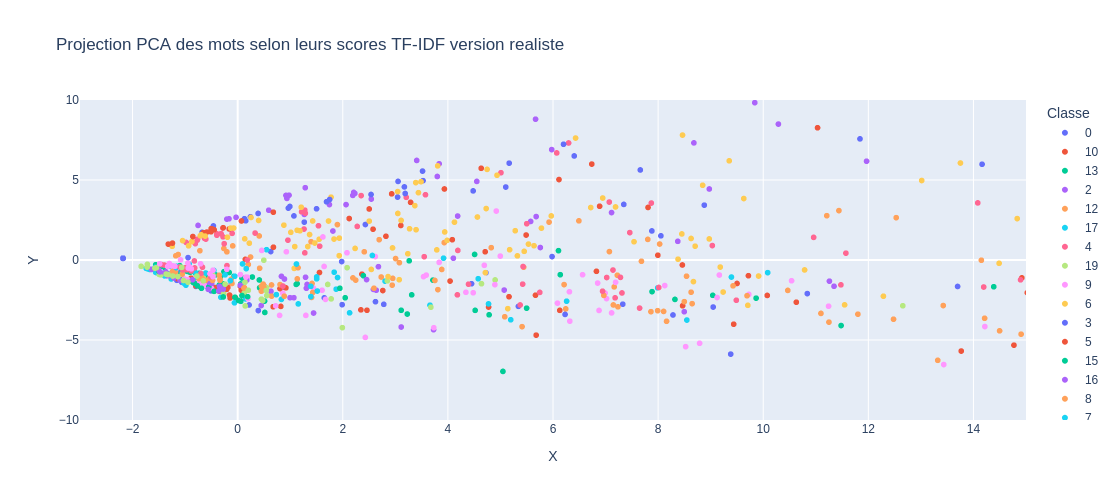

In [33]:
# 5. Visualisation
df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Classe": [str(y) for y in Y],  # Pour que ce soit une variable catégorielle
    "Mot": vocabulaire
})

fig = px.scatter(df_pca, x="PC1", y="PC2", color="Classe",
                 hover_data=["Mot"],
                 title="Projection PCA des mots selon leurs scores TF-IDF version realiste",
                 labels={"PC1": "X", "PC2": "Y"})

fig.update_layout(
    width=800,
    height=500,
    xaxis_range=[-3, 15],
    yaxis_range=[-10, 10]
)
    

fig.show()


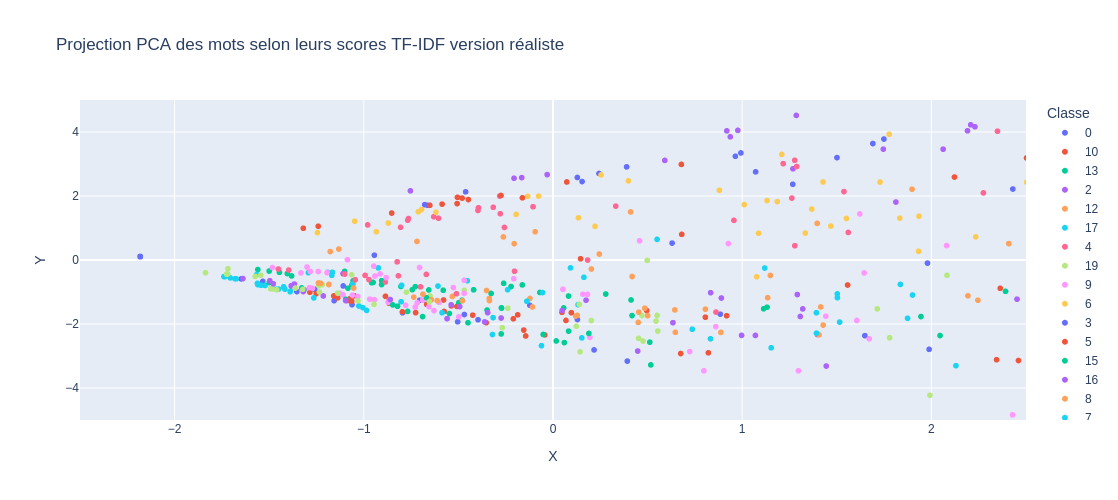

In [32]:
# 5. Visualisation
df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Classe": [str(y) for y in Y],  # Pour que ce soit une variable catégorielle
    "Mot": vocabulaire
})

fig = px.scatter(df_pca, x="PC1", y="PC2", color="Classe",
                 hover_data=["Mot"],
                 title="Projection PCA des mots selon leurs scores TF-IDF version réaliste",
                 labels={"PC1": "X", "PC2": "Y"})

fig.update_layout(
    width=800,
    height=500,
    xaxis_range=[-2.5, 2.5],
    yaxis_range=[-5, 5]
)
    

fig.show()


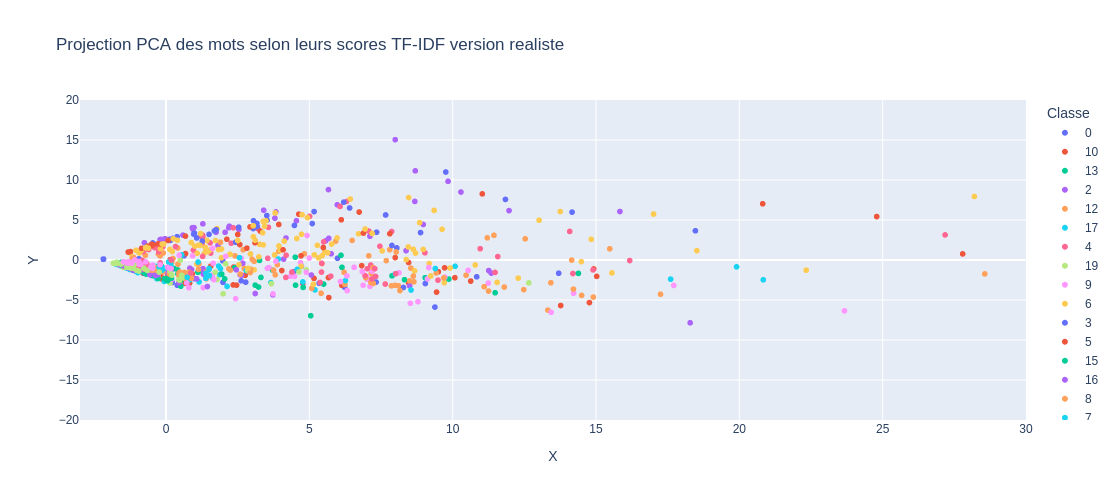

In [31]:
# 5. Visualisation
df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Classe": [str(y) for y in Y],  # Pour que ce soit une variable catégorielle
    "Mot": vocabulaire
})

fig = px.scatter(df_pca, x="PC1", y="PC2", color="Classe",
                 hover_data=["Mot"],
                 title="Projection PCA des mots selon leurs scores TF-IDF version realiste",
                 labels={"PC1": "X", "PC2": "Y"})

fig.update_layout(
    width=800,
    height=500,
    xaxis_range=[-3, 30],
    yaxis_range=[-20, 20]
)
    

fig.show()


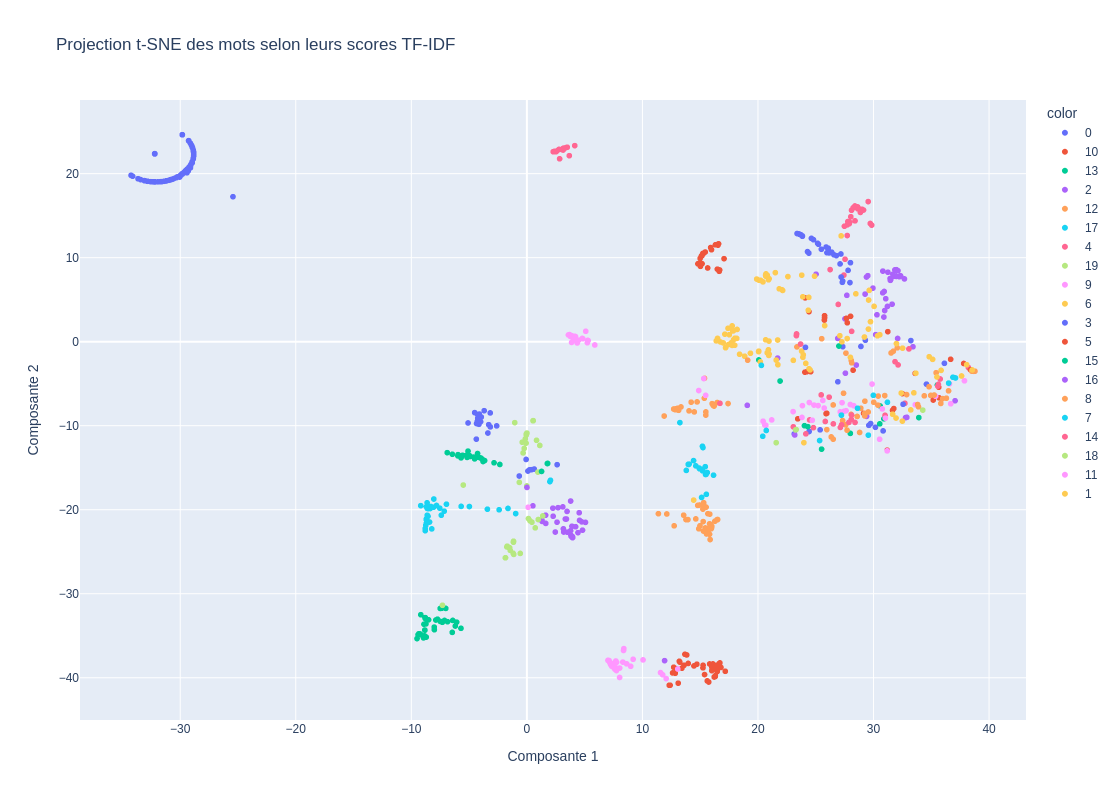

In [56]:
from sklearn.manifold import TSNE
import plotly.express as px
# X_realiste.shape = (2000*20) 2000 mots * 20 groupes 
# Y = 2000 labels 
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_realiste)
groupes_labels = [i for i in range(20)]

df_tsne = pd.DataFrame({
    "Composante 1": X_tsne[:, 0],
    "Composante 2": X_tsne[:, 1],
    "Mot": vocabulaire,
    "Groupe": Y
})

fig = px.scatter(
    df_tsne, x="Composante 1", y="Composante 2",
    color=df_tsne["Groupe"].astype(str),
    hover_data=["Mot"],
    title="Projection t-SNE des mots selon leurs scores TF-IDF",
    labels={"Groupe": "Classe"}
)

fig.update_layout(
    width=800,
    height=800
)

fig.show()


In [58]:
# export le dict 2000 mots 
len(vocabulaire)

distances = np.linalg.norm(X_tsne, axis=1)
indices_top = np.argsort(distances)[::-1][:100]  # top 100 plus grandes distances
mots_top = [Y[i] for i in indices_top]

# Écriture dans un fichier texte
with open("mots_discriminants.txt", "w", encoding="utf-8") as f:
    for mot in mots_top:
        f.write(mot + "\n")

2000

In [64]:
dict_export = dict()
for num_groupe, liste_tuple in dict_top_mots_par_groupe.items():
    temp = list()
    for mot, _ in liste_tuple:
        temp.append(mot)
    dict_export[num_groupe] = temp
    

In [66]:
series_export = pd.Series(dict_export)
series_export.to_json("mots_par_groupe.json", orient="index", force_ascii=False)

In [67]:
dict_tout = set()
for nom, groupe in groupes20.items():
    for message in groupe:
        dict_tout.update(message)

In [ ]:
len(dict_tout)